In [1]:
# Basic imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# XGBoost
from xgboost import XGBClassifier

In [2]:
# CSV files (use same 4 for consistency)
csv_files = [
    '../data/Monday-WorkingHours.pcap_ISCX.csv',
    '../data/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    '../data/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    '../data/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
]

# Load and combine
data_list = [pd.read_csv(f) for f in csv_files]
data = pd.concat(data_list, ignore_index=True)

# Clean column names
data.columns = data.columns.str.strip()

# Encode labels: BENIGN=0, ATTACK=1
data['Label'] = data['Label'].apply(lambda x: 0 if x=='BENIGN' else 1)

# Check distribution
print(data['Label'].value_counts())

Label
0    1043739
1     286993
Name: count, dtype: int64


In [3]:
# Features & target
X = data.drop('Label', axis=1)
y = data['Label']

# Replace infinities and NaNs
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train & test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# Train XGBoost classifier
xgb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1, 
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)

/Users/charanmandakuriti/SmartIDS/venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [12:18:49] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [5]:
# Predictions
y_pred = xgb_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9991132719887882


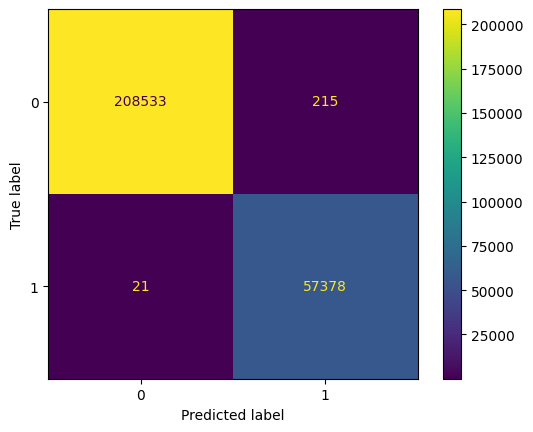

In [6]:
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test)
plt.show()

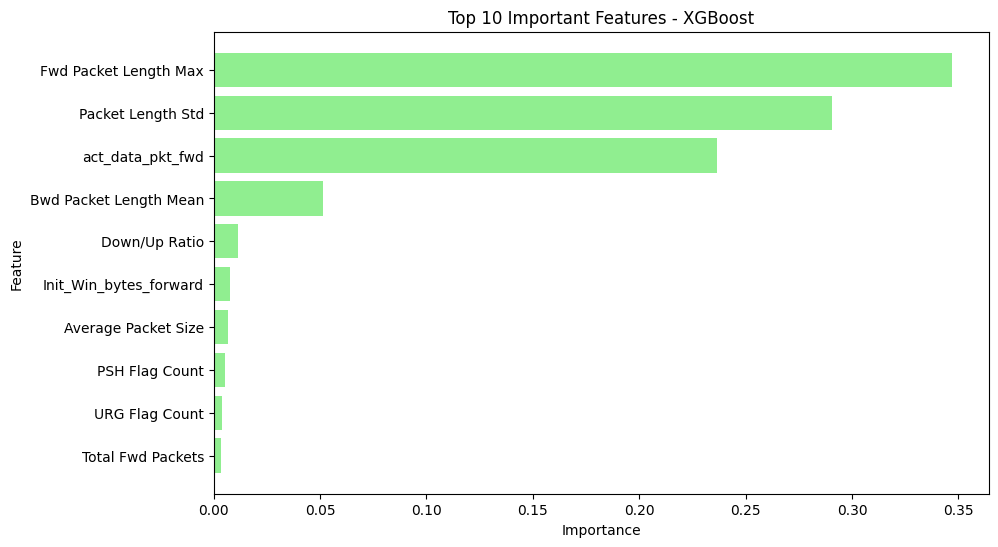

In [7]:
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

top10 = feat_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['Feature'], top10['Importance'], color='lightgreen')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features - XGBoost')
plt.gca().invert_yaxis()
plt.show()

In [9]:
import joblib
joblib.dump(xgb_model, './models/xgboost.pkl')
print("XGBoost model saved!")

XGBoost model saved!
